Dataset Shape: (1000, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB

Missing Values:
ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG          

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


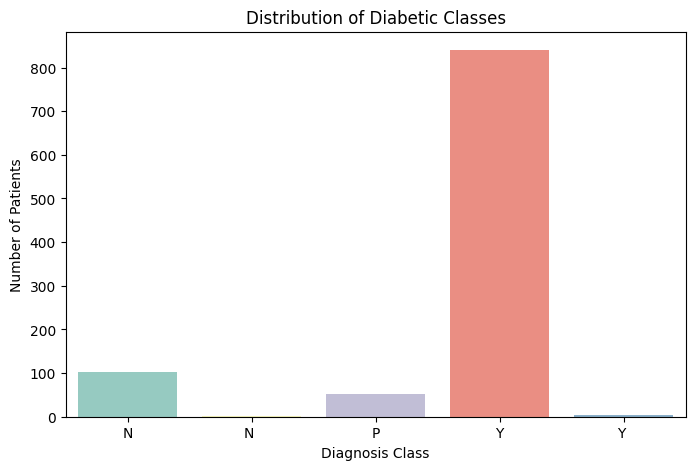

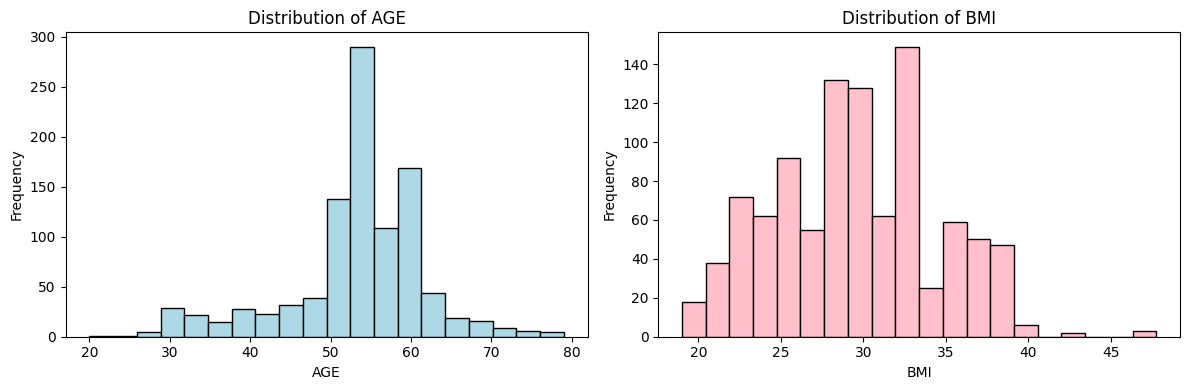

In [1]:
#1.data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

ds = pd.read_csv("Diabetes Dataset/Dataset of Diabetes .csv")

#2.Data Inspecton:~
#checkong dimensions (# rows & # columns)
print(f"Dataset Shape: {ds.shape}")
#column names and data types
print("\nDataset Info:")
ds.info() #displaying info about DataFrame

#to check for missing values (in each column) & count them & disply them
print("\nMissing Values:")
print(ds.isnull().sum()) 

#3.Statistical Analysis & Visualisation:~
#Generating descriptive statistics for columns
    #Count, mean, standard deviation
    #Minimum, 25th percentile, median (50th), 75th percentile, maximum
print("\nDescriptive Statistics:")
display(ds.describe())


#Visualising class distribution
# Create a bar plot to show the count of each class
plt.figure(figsize=(8, 5)) #creating new figure for plotting
sb.countplot(x='CLASS', data=ds, hue='CLASS', palette='Set3', legend=False) #crating count plot (x axis, dataframe,colour scheme)
plt.title('Distribution of Diabetic Classes') 
plt.xlabel('Diagnosis Class')
plt.ylabel('Number of Patients')
plt.show()

# Creating a figure for Age and BMI
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 

#selecting age and creating histogram plot, using first subplot & dividing data into 20 bars

ds['AGE'].plot.hist(ax=axes[0], bins=20, color='lightblue', edgecolor='black')
axes[0].set_title('Distribution of AGE')
axes[0].set_xlabel('AGE')

ds['BMI'].plot.hist(ax=axes[1], bins=20, color='pink', edgecolor='black')
axes[1].set_title('Distribution of BMI')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# fix inconsistency in Gender by convert them all to uppercase(f/F)
ds["Gender"] = ds["Gender"].str.upper()

# fix inconsistency in CLASS by remove spaces 
ds["CLASS"] = ds["CLASS"].str.strip()

# map N, Y, P to proper values 
class_mapping = {'N': 'Non-Diabetic', 'Y': 'Diabetic', 'P': 'Predict-Diabetic'}
ds['CLASS'] = ds['CLASS'].map(class_mapping)

# encode Gender to F = 0, M = 1
gender_encoder = LabelEncoder()
ds["Gender"] = gender_encoder.fit_transform(ds["Gender"])

# encode class to Diabetic = 0, Non-Diabetic = 1, Predict-Diabetic = 2
class_encoder = LabelEncoder()
ds["CLASS"] = class_encoder.fit_transform(ds["CLASS"])

# encoding verification
print("encoding verification")
print(f"Gender: {ds['Gender'].unique()} -> {list(zip(gender_encoder.classes_, [0,1]))}")
print(f"CLASS: {ds['CLASS'].unique()} -> {list(zip(class_encoder.classes_, range(3)))}")

# separate features from target 
patient_features = ds.drop('CLASS', axis=1)
diagnosis_target = ds['CLASS']

# separate features verification
print("\nseparate features verification")
print(f"Patient features: {patient_features.shape}") 
print(f"Diagnosis labels: {diagnosis_target.shape}") 

# feature scaling
scaleStandard = StandardScaler()
patient_features = scaleStandard.fit_transform(patient_features)

# feature scaling verification
print("\nfeature scaling verification")
print(f"Mean: {np.mean(patient_features, axis=0)[0]:.2f} (should be ~0)")
print(f"Std: {np.std(patient_features, axis=0)[0]:.2f} (should be ~1)")

# data splitting
# split into 60% train 40% temporary 
X_train, X_temp, y_train, y_temp = train_test_split(patient_features, diagnosis_target, random_state = 23, test_size = 0.4, stratify=diagnosis_target) 
print(X_train.shape)

# split temporary into 20% test and 20% validation 
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 23, stratify = y_temp)

# data splitting verification
print("\ndata splitting verification")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Validation set: {X_val.shape}")

# train the decision tree model
dt_model = DecisionTreeClassifier(random_state = 23)
dt_model.fit(X_train, y_train)

# training verification
train_predictions = dt_model.predict(X_train)
train_accuracy = (train_predictions == y_train).mean()

print("\nmodel training verification")
print(f"Training accuracy: {train_accuracy:.4f}")
print("Sample predictions vs actual:")
for i in range(5):
    print(f"  Predicted: {train_predictions[i]}, Actual: {y_train.iloc[i]}")

encoding verification
Gender: [0 1] -> [('F', 0), ('M', 1)]
CLASS: [1 2 0] -> [('Diabetic', 0), ('Non-Diabetic', 1), ('Predict-Diabetic', 2)]

separate features verification
Patient features: (1000, 13)
Diagnosis labels: (1000,)

feature scaling verification
Mean: 0.00 (should be ~0)
Std: 1.00 (should be ~1)
(600, 13)

data splitting verification
Training set: (600, 13)
Test set: (200, 13)
Validation set: (200, 13)

model training verification
Training accuracy: 1.0000
Sample predictions vs actual:
  Predicted: 0, Actual: 0
  Predicted: 0, Actual: 0
  Predicted: 0, Actual: 0
  Predicted: 0, Actual: 0
  Predicted: 0, Actual: 0


Model Evaluation (Initial Decision Tree)
Validation Accuracy: 0.9750
Test Accuracy: 0.9800

Classification Report (Validation Set):
                  precision    recall  f1-score   support

        Diabetic       0.99      0.98      0.99       169
    Non-Diabetic       0.87      1.00      0.93        20
Predict-Diabetic       0.91      0.91      0.91        11

        accuracy                           0.97       200
       macro avg       0.92      0.96      0.94       200
    weighted avg       0.98      0.97      0.98       200



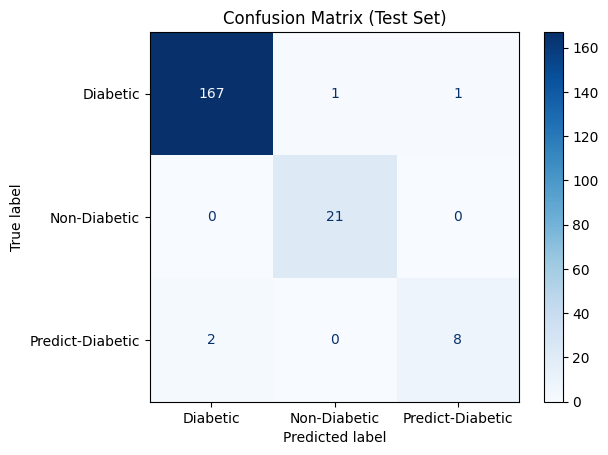


 Best Parameters Found:
{'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_split': 2}

 Optimized Model Performance:
Validation Accuracy: 0.9750
Test Accuracy: 0.9750


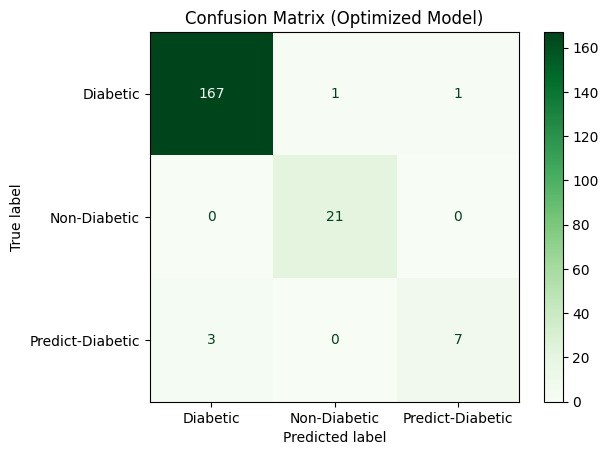


Classification Report (Optimized Model):
                  precision    recall  f1-score   support

        Diabetic       0.98      0.99      0.99       169
    Non-Diabetic       0.95      1.00      0.98        21
Predict-Diabetic       0.88      0.70      0.78        10

        accuracy                           0.97       200
       macro avg       0.94      0.90      0.91       200
    weighted avg       0.97      0.97      0.97       200



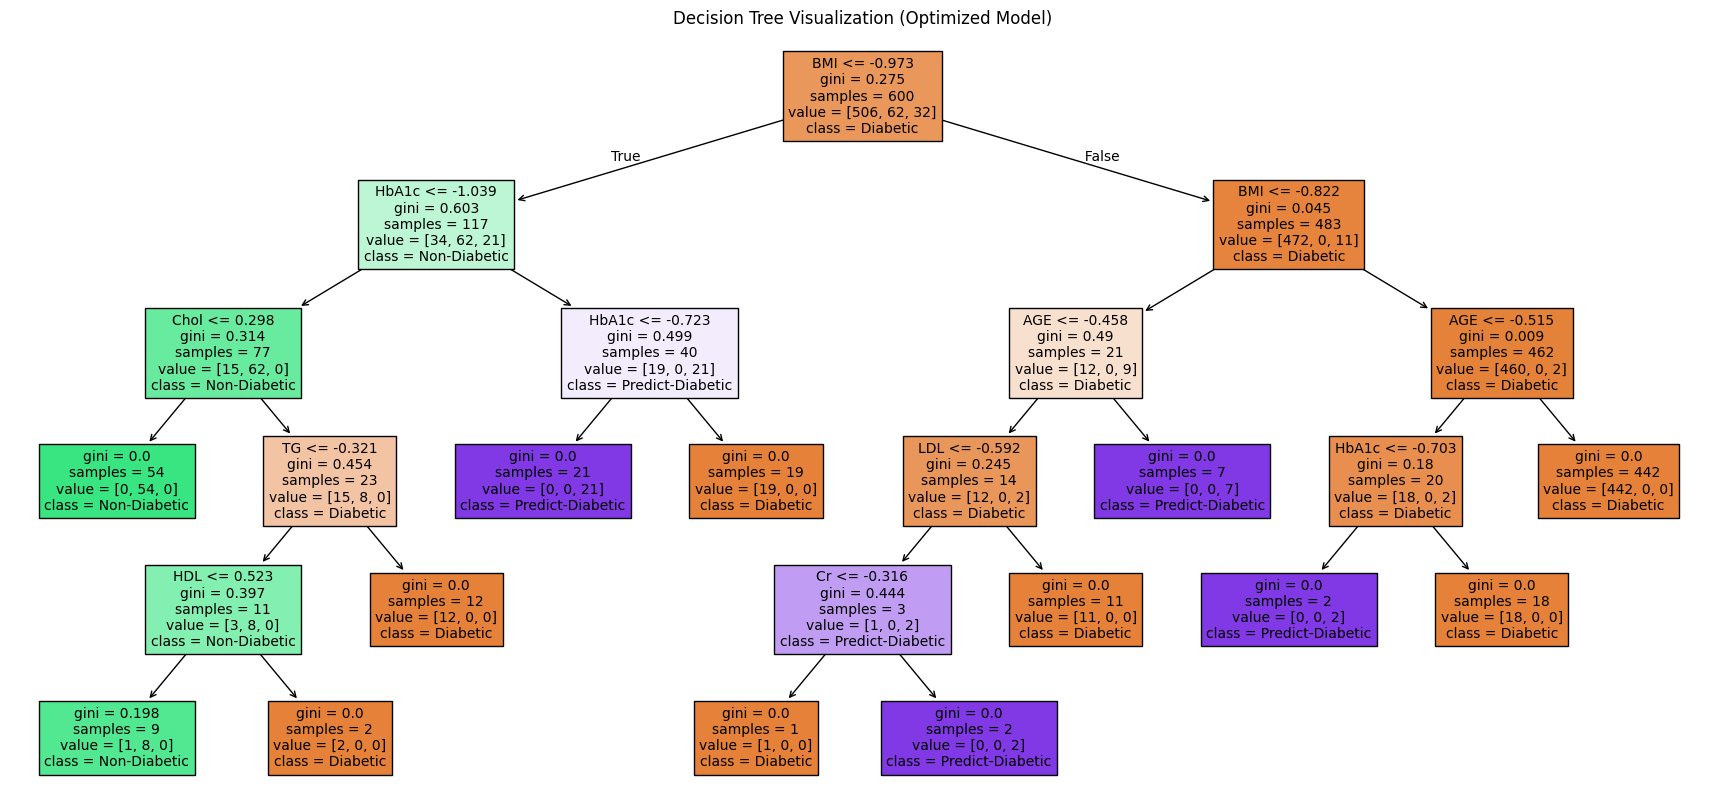

In [3]:
#  Model Evaluation & Visualization

# Focus: Evaluate model performance, reduce overfitting, visualize results

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

#  Make predictions on validation and test sets
y_pred_val = dt_model.predict(X_val)
y_pred_test = dt_model.predict(X_test)

# Evaluate performance
print("Model Evaluation (Initial Decision Tree)")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

print("\nClassification Report (Validation Set):")
print(classification_report(y_val, y_pred_val, target_names=class_encoder.classes_))

#  Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_encoder.classes_)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (Test Set)")
plt.show()

#
#  Overfitting (Hyperparameter Tuning)
param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=23),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

#  model and parameters
print("\n Best Parameters Found:")
print(grid_search.best_params_)

final_dt_model = grid_search.best_estimator_

# Evaluate after tuning
y_pred_val_final = final_dt_model.predict(X_val)
y_pred_test_final = final_dt_model.predict(X_test)

print("\n Optimized Model Performance:")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred_val_final):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test_final):.4f}")

#
# Confusion Matrix (Optimized Model)
cm_final = confusion_matrix(y_test, y_pred_test_final)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=class_encoder.classes_)
disp_final.plot(cmap="Greens", values_format='d')
plt.title("Confusion Matrix (Optimized Model)")
plt.show()

print("\nClassification Report (Optimized Model):")
print(classification_report(y_test, y_pred_test_final, target_names=class_encoder.classes_))

#
# Visualize Final Decision Tree
feature_names = [col for col in ds.columns if col != 'CLASS']

plt.figure(figsize=(22, 10))
plot_tree(
    final_dt_model,
    filled=True,
    feature_names=feature_names,
    class_names=class_encoder.classes_,
    fontsize=10
)
plt.title("Decision Tree Visualization (Optimized Model)")
plt.show()
